<h1><center>Laboratorio 7: Ensamblaje, Optimización de Hiperparámetros e Interpretabilidad 🤖</center></h1>

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos</strong></center>

---

### Cuerpo Docente

- Profesores: Pablo Badilla y Diego Cortez
- Auxiliares: Valentina Rojas y Melanie Peña
- Ayudantes: Javiera Arévalo, Tamara Carrasco y Ignacio Reyes

### Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1: Bryan Cabezas
- Nombre de alumno 2: Gonzalo Sobarzo

---

### Reglas

- **Grupos de 2 personas**
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Prohibido copiar.
- Uso de LLM (Copilot, Claude, Antigravity, Cursor, etc.) restringido a consultas, documentación y corrección de errores.

## Temas a tratar

- Ensamblaje: Bagging (`RandomForest`), Boosting (`XGBoost`, `LightGBM`) y Stacking.
- Optimización de Hiperparámetros con `Optuna` y visualización interactiva con `optuna-dashboard`.
- Interpretabilidad global: `Permutation Feature Importance (PFI)`.
- Interpretabilidad local: `SHAP`.

### Objetivos principales del laboratorio

- Aplicar y comparar métodos de ensamblaje sobre un problema de clasificación de texto.
- Optimizar hiperparámetros de LightGBM usando Optuna y visualizar el proceso con `optuna-dashboard`.
- Interpretar las predicciones del modelo usando PFI y SHAP.

El laboratorio deberá ser desarrollado sin el uso indiscriminado de iteradores nativos de Python (aka "for", "while"). La idea es que aprendan a exprimir al máximo las funciones optimizadas que nos entrega `pandas`.

### Instalamos librerías 😸

In [1]:
!uv add nltk lightgbm xgboost optuna shap scikit-learn plotly certifi

Resolved 152 packages in 24ms
Audited 144 packages in 155ms


In [2]:
import ssl

import certifi
import nltk

ssl._create_default_https_context = lambda: ssl.create_default_context(
    cafile=certifi.where()
)  # ESTO FUE PARA DESCARGAR STOPWORDS DE NLTK EN MAC

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /Users/bryan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [19]:
import warnings

import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import optuna
import pandas as pd
import plotly.express as px
import shap
from lightgbm import LGBMClassifier
from nltk import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from optuna.visualization import (
    plot_optimization_history,
    plot_parallel_coordinate,
    plot_param_importances,
)
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split  # noqa: F401
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

RANDOM_STATE = 42
optuna.logging.set_verbosity(optuna.logging.WARNING)

# 1. ¿Quién es Bat Cow?

<p align="center">
  <img src="https://i.imgur.com/D9f1RHy.jpg" width="350">
</p>

En vez de estar desarrollando las evaluaciones correspondientes a su curso, su profesor de catedra y su auxiliar discuten acerca la alineación (i.e., si es heroe o villano) del personaje de ficción Bat-Cow.

El cuerpo docente, no logra ponerse de acuerdo si el personaje es bueno, neutral o malo: el auxiliar plantea que Bat-cow posee una siniestra mirada, intrigante pero común característica de los personajes malvados.
Por otra parte, extendiendo las ideas de Rousseau, el profesor plantea que tal como los humanos no nacen malos, no existe motivo por el cual una vaca con superpoderes deba serlo.

Sin embargo, ambos concuerdan que es difícil estimar la alineación solo usando los atributos físicos. Es por esto que les solicitan construir y optimizar un clasificador basado en texto que analice la alineación de cada personaje basado en su historia personal.

Para este laboratorio deben trabajar con los datos `df_comics.csv` y `comics_no_label.csv` subidos a u-cursos.

In [4]:
df_comics = pd.read_csv("df_comics.csv", index_col=0)
df_comics_no_label = pd.read_csv("comics_no_label.csv", index_col=0)
df_comics = df_comics.dropna(subset=["history_text"])
df_comics

,name,real_name,full_name,overall_score,history_text,powers_text,intelligence_score,strength_score,speed_score,durability_score,...,has_flight,has_accelerated_healing,has_weapons_master,has_intelligence,has_reflexes,has_super_speed,has_durability,has_stamina,has_agility,has_super_strength
0,3-D Man,"Delroy Garrett, Jr.","Delroy Garrett, Jr.",6,"Delroy Garrett, Jr. grew up to become a track ...",NaN,85,30,60,60,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,A-Bomb,Richard Milhouse Jones,Richard Milhouse Jones,20,"Richard ""Rick"" Jones was orphaned at a young ...","On rare occasions, and through unusual circu...",80,100,80,100,...,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0
3,Aa,Aa,NaN,12,Aa is one of the more passive members of the P...,NaN,80,50,55,45,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Aaron Cash,Aaron Cash,Aaron Cash,5,Aaron Cash is the head of security at Arkham A...,NaN,80,10,25,40,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,Aayla Secura,Aayla Secura,NaN,8,ayla Secura was a Rutian Twi'lek Jedi Knight (...,NaN,90,40,45,55,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1445,Zatanna,Zatanna Zatara,Zatanna Zatara,10,Zatanna is the daughter of adventurer John Zat...,Zatanna is genetically talented with her magi...,90,10,25,30,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1446,Zero,DWN-∞: Zero,DWN-∞: Zero,18,Zero was created by the late Dr. Albert Wily ...,NaN,80,100,100,100,...,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1447,Zoom (New 52),Hunter Zolomon,NaN,20,"Hunter Zolomon is better known as Zoom, a spee...",After tricking Barry Allen and Wally West into...,95,50,100,75,...,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1448,Zoom,Hunter Zolomon,Hunter Zolomon,9,Hunter Zolomon had a troubled relationship wi...,"Zoom is able to alter time, to make himself ev...",75,10,100,30,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


## 1.1 Obtención de Features y Bag of Words

<p align="center">
  <img src="https://media0.giphy.com/media/eIUpSyzwGp0YhAMTKr/200.gif" width="300">
</p>

`bag of words` es un modelo de conteo utilizado en NLP que genera una representación vectorial para cada documento a través del conteo de las palabras que contienen.

<p align="center">
  <img src="https://user.oc-static.com/upload/2020/10/23/16034397439042_surfin%20bird%20bow.png" width="500">
</p>

Para facilitar el conteo transformamos cada documento en un vector mediante **tokenización**:

In [6]:
docs = ["The teacher rocks like a good rock & roll", "the rock is the best actor in the world"]
docs_tokenizados = [word_tokenize(doc) for doc in docs]
docs_tokenizados

[['The', 'teacher', 'rocks', 'like', 'a', 'good', 'rock', '&', 'roll'],
 ['the', 'rock', 'is', 'the', 'best', 'actor', 'in', 'the', 'world']]

Podemos mejorar la tokenización con:

- **Stemming**: transforma palabras a su forma raíz (*running → run*, *rocks → rock*).
- **Eliminación de Stopwords**: elimina palabras muy frecuentes que entorpecen la clasificación (*the*, *is*, *a*, ...).

<p align="center">
  <img src="https://devopedia.org/images/article/218/8583.1569386710.png" width="300">
</p>

In [5]:
stop_words = stopwords.words("english")


class StemmerTokenizer:
    def __init__(self):
        self.ps = PorterStemmer()

    def __call__(self, doc):
        doc_tok = word_tokenize(doc)
        doc_tok = [t for t in doc_tok if t not in stop_words]
        return [self.ps.stem(t) for t in doc_tok]


tokenizador = StemmerTokenizer()

docs = [
    "The teacher rocks like a good rock & roll",
    "the rock is the best actor in the world",
    "New York is a beautiful city",
]

print("Con StemmerTokenizer:")
print([tokenizador(doc) for doc in docs])
print("\nSin preprocesamiento:")
print([word_tokenize(doc) for doc in docs])

Con StemmerTokenizer:
[['the', 'teacher', 'rock', 'like', 'good', 'rock', '&', 'roll'], ['rock', 'best', 'actor', 'world'], ['new', 'york', 'beauti', 'citi']]

Sin preprocesamiento:
[['The', 'teacher', 'rocks', 'like', 'a', 'good', 'rock', '&', 'roll'], ['the', 'rock', 'is', 'the', 'best', 'actor', 'in', 'the', 'world'], ['New', 'York', 'is', 'a', 'beautiful', 'city']]


#### Al Estilo Scikit

Scikit implementa `bag of words` con `CountVectorizer()`. Además soporta **n-gramas**: secuencias contiguas de n palabras que se tratan como un único token. Esto permite capturar contexto local que los unigramas pierden.

| Tipo | n | Tokens de `"nueva york ciudad"` |
|------|---|--------------------------------|
| Unigrama | 1 | `nueva`, `york`, `ciudad` |
| Bigrama | 2 | `nueva york`, `york ciudad` |
| Trigrama | 3 | `nueva york ciudad` |

Con `ngram_range=(1,2)` el vectorizador incluye **unigramas y bigramas** simultáneamente. Los bigramas son especialmente útiles para capturar expresiones compuestas como `bat cow`, `spider man` o `super hero` que pierden su significado si se separan.

El parámetro `max_features` limita el vocabulario a los n tokens más frecuentes, controlando la dimensionalidad de la representación.

In [8]:
bow = CountVectorizer(tokenizer=StemmerTokenizer(), ngram_range=(1, 2))
df_bow = bow.fit_transform(docs)
pd.DataFrame(df_bow.toarray(), columns=bow.get_feature_names_out())

,&,& roll,actor,actor world,beauti,beauti citi,best,best actor,citi,good,...,rock,rock &,rock best,rock like,roll,teacher,teacher rock,world,york,york beauti
0,1,1,0,0,0,0,0,0,0,1,...,2,1,0,1,1,1,1,0,0,0
1,0,0,1,1,0,0,1,1,0,0,...,1,0,1,0,0,0,0,1,0,0
2,0,0,0,0,1,1,0,0,1,0,...,0,0,0,0,0,0,0,0,1,1


#### Combinando Features: `ColumnTransformer`

Para combinar en un solo paso el preprocesamiento de texto y numérico, usamos `ColumnTransformer`. Este aplica transformadores distintos a subconjuntos de columnas del DataFrame y concatena el resultado en una sola matriz de features lista para entrenar.

<p align="center">
  <img src="https://c.tenor.com/LkQzw7k5DV4AAAAd/anime-hacking.gif" width="300">
</p>

El `preprocessing_transformer` que usaremos a lo largo del lab combina:

- **`CountVectorizer`** con `StemmerTokenizer`, `ngram_range=(1,2)` y `max_features=500` → aplicado sobre la columna `history_text`.
- **`MinMaxScaler`** → aplicado sobre los 6 atributos numéricos de habilidad: `intelligence_score`, `strength_score`, `speed_score`, `durability_score`, `power_score`, `combat_score`.

In [6]:
preprocessing_transformer = ColumnTransformer(
    transformers=[
        (
            "MinMaxScaler",
            MinMaxScaler(),
            [
                "intelligence_score",
                "strength_score",
                "speed_score",
                "durability_score",
                "power_score",
                "combat_score",
            ],
        ),
        (
            "bow",
            CountVectorizer(
                tokenizer=StemmerTokenizer(),
                max_features=500,
                ngram_range=(1, 2),
            ),
            "history_text",
        ),
    ]
)

## 1.2 Diseño de Baseline y Primer Entrenamiento [1 Punto]

<p align="center">
  <img src="https://pa1.narvii.com/6374/9eaec1b7bf9157334151452a669516f9a78b954c_hq.gif" width="300">
</p>

### 1.2.1 ¿Qué es un Baseline? [0.2 Puntos]

Antes de entrenar modelos complejos, es fundamental establecer un punto de referencia mínimo. Responde las siguientes preguntas con tus propias palabras:

1. **¿Qué es un baseline en Machine Learning?** ¿Para qué sirve establecerlo antes de evaluar modelos más sofisticados?
2. **¿Por qué usamos un `DummyClassifier` como baseline?** ¿Qué implica que un modelo "real" no logre superar su rendimiento?

# Escribe aquí la respuesta
- 1. El baseline es un modelo de clasificación que se utiliza como referencia y como base para evaluar otros modelos más sotisficados. Se establece para comparar las métricas de rendimiento contra los otros modelos y ver si los modelos más complejos realmente aportan una mejora.
- 2. Se utiliza DummyClassifier como baseline ya que es un modelo simple que hace predicciones basadas en la distribución de las clases de los datos, sin aprender de los datos de entrada y de manera aleatoria. Si un modelo más complejo no supera el rendimiento, significa que no está aprendiendo un patron útil de los datos y no es mejor que un modelo basado en aleatorización, por lo cúal es mejor descartarlo.

---

### 1.2.2 Implementación [0.6 Puntos]

Genere un `Pipeline` con las características de 1.1 y un `DecisionTreeClassifier()` por defecto.

Separe el dataset en entrenamiento/prueba (80/20, estratificado, `random_state=RANDOM_STATE`). Entrene, reporte `classification_report` y compare con un `DummyClassifier(strategy="stratified")`.

**To-do:**
- [ ] Pipeline con preprocesamiento → `DecisionTreeClassifier`.
- [ ] Holdout estratificado 80/20.
- [ ] `classification_report` del baseline.
- [ ] Entrenar `DummyClassifier` y comparar.

In [15]:
#### Código aquí ####
pipeline_dt = Pipeline(
    steps=[
        ("preprocesamiento", preprocessing_transformer),
        ("modelo", DecisionTreeClassifier(random_state=RANDOM_STATE)),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    df_comics.drop(columns=["alignment"]),
    df_comics["alignment"],
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df_comics["alignment"],
)

pipeline_dt.fit(X_train, y_train)
y_pred_dt = pipeline_dt.predict(X_test)

print("Classification Report - Decision Tree:")
print(classification_report(y_test, y_pred_dt))

Classification Report - Decision Tree:
              precision    recall  f1-score   support

         Bad       0.41      0.43      0.42        86
        Good       0.66      0.61      0.64       148
     Neutral       0.10      0.13      0.11        23

    accuracy                           0.51       257
   macro avg       0.39      0.39      0.39       257
weighted avg       0.53      0.51      0.52       257



In [9]:
pipeline_dummy = Pipeline(
    steps=[
        ("preprocesamiento", preprocessing_transformer),
        ("modelo", DummyClassifier(strategy="stratified", random_state=RANDOM_STATE)),
    ]
)

pipeline_dummy.fit(X_train, y_train)
y_pred_dummy = pipeline_dummy.predict(X_test)

print("Classification Report - Dummy Classifier:")
print(classification_report(y_test, y_pred_dummy))

Classification Report - Dummy Classifier:
              precision    recall  f1-score   support

         Bad       0.32      0.34      0.33        86
        Good       0.58      0.56      0.57       148
     Neutral       0.12      0.13      0.12        23

    accuracy                           0.45       257
   macro avg       0.34      0.34      0.34       257
weighted avg       0.46      0.45      0.45       257



### 1.2.3 Pregunta de Cierre [0.2 Puntos]

**Pregunta:** ¿El `DecisionTreeClassifier` supera al `DummyClassifier`? ¿Qué concluyes de esto sobre lo que ha aprendido el modelo? Además responde:

1. ¿Por qué el accuracy puede ser una métrica engañosa en este problema? ¿Qué métrica es más apropiada si las clases están desbalanceadas?
2. ¿Por qué se usa el parámetro `stratify` en el `train_test_split`? ¿Qué problema evitamos al usarlo?
3. ¿Es mejor el clasificador que su versión aleatoria? ¿Podemos avanzar con confianza de que estamos clasificando mejor que si por ejemplo, tiraramos un dado con 3 caras?

> **Respuesta:**

In [25]:
df_comics["alignment"].value_counts()

alignment
Good       743
Bad        429
Neutral    113
Name: count, dtype: int64

# Escribe aquí la respuesta
El modelo DecisionTreeClassifier efectivamente supera al DummyClassifier en las métricas globales, alcanzando un Accurary de 54% frente al 45% de la línea base, y un Macro F1-Score de 0.42 frente a 0.34. Esto demuestra que el árbol no esta prediciendo al azar y que logró encontrar patrones a partir de las características de los datos para diferenciar las clases mayoritarias. Aún asi, el modelo presenta un rendimiento muy bajo en la clase minoritaria "Neutral" de 0.12 en F1-score. Como también el rendimiento aunque mejoró, sigue presentando un modelo con un rendimiento pobre, confirmando que sigue siendo un modelo no confiable.

- 1. Al presentar un desbalanceo de datos, con 743 buenos, 429 malos y 113 neutrales, el modelo aprendera de mejor manera los patrones de la clase mayoritaria al presentar más datos, por lo cual el modelo se equivocará en menor medida en esos datos, haciendo que el accuracy aumente, pero puede ocurrir que no clasifique correctamente las clases minoritarias, las cuales en su mayoría son las más importantes al presentar en menor medida, por lo cual esa métrica estaría sesgada. Una métrica más apropiada sería F1-Score, ya que calcula la media armónica entre la Precisión (cuántos de los clasificados como positivos eran realmente positivos) y el Recall (cuántos de los positivos reales logró capturar el modelo). Al balancear ambas, el F1-score penaliza los modelos que predicen únicamente la clase más frecuente, exigiendo un buen desempeño tanto en la clasificación de la clase mayoritaria como en la minoritaria.

- 2. Se utiliza stratify en la división de entrenamiento y testeo, debido que mantiene la misma propoción en ambos conjuntos, evitando el problema de que en un conjunto únicamente existan datos de la clase mayoritaria y cero o muy pocos valores de la clase minoritaria, generando un modelo que no generalice correctamente.


- 3. Sí, el clasificador Decision Tree es mejor que su versión aleatoria y que un dado de 3 caras, pero la mejora no es sustancial por lo que no se puede avanzar con confianza. Un dado perfecto de 3 caras acertaría el 33.3% de las veces, el árbol de decisión logra un 54% de Accuracy, lo cual es más alto. Sin embargo, el Macro F1-Score (0.42 del árbol vs 0.34 del Dummy) muestra un rendimiento real en la clasificación de las categorías muy pobre. EL modelo tiene un desempeño muy bajo en la clase "Neutral" de 0.12 en F1-Score, siendo practicamente similar al azar. Por lo que en si, no es un modelo confiable en producción, superando apenas la línea base del comportamiento aleatorio. 

---

# 2. Métodos de Ensamblaje [2 Puntos]

<p align="center">
  <img src="https://media.giphy.com/media/l0HlHFRbmaZtBRhXG/giphy.gif" width="300">
</p>

Los métodos de ensamblaje combinan múltiples modelos para obtener predicciones más robustas. Exploraremos tres estrategias:

| Estrategia | Idea clave | Ejemplo |
|------------|-----------|---------|
| **Bagging** | Modelos en paralelo sobre subconjuntos aleatorios | Random Forest |
| **Boosting** | Modelos en secuencia, cada uno corrige al anterior | XGBoost, LightGBM |
| **Stacking** | Predicciones de modelos base como input de un meta-modelo | StackingClassifier |

Todos usarán el mismo `preprocessing_transformer` de la sección 1.

## 2.1 Bagging: Random Forest [0.5 Puntos]

### 2.1.1 Descripción del algoritmo [0.2 Puntos]

Describe con tus propias palabras cómo funciona el **Bagging (Bootstrap Aggregating)**. La descripción debe cubrir los siguientes tres pasos:

1. **Generación de subconjuntos**: ¿Cómo se obtienen los subconjuntos de entrenamiento a partir del dataset original? ¿Se usa todo el dataset en cada uno? ¿Se pueden repetir instancias?
2. **Entrenamiento**: ¿Qué se entrena sobre cada subconjunto? ¿Los modelos se entrenan de forma dependiente o independiente entre sí?
3. **Agregación**: ¿Cómo se combinan las predicciones de todos los modelos para obtener una respuesta final?


# Escribe aquí la respuesta
- El bagging es un método de ensamble diseñada para mejorar la estabilidad y precisión de los modelo, reduciendo la varianza y evitando sobreajuste.
- Primero genera múltiples subconjuntos de datos a partir del dataset original, mediante el método llamado muestreo con reemplazo, donde aleatoriamente se obtiene un dato y se registra en un sobconjunto y nuevamente ese registro se agrega al conjunto inicial al ser con reemplazo. No se utiliza todo el dataset en los subconjuntos. Cada subconjunto tiene el mismo tamaño (N) que el dataset original, pero debido al azar no contiene los mismos datos originales, sino que algunos repetidos y otros no. 
- Una vez creados los M subconjuntos obtenidos en el paso anterior, comienza la etapa de Entrenamiento, donde sobre cada subconjunto se entrena un modelo base individual, utilizando árboles de decisión complejos profundos sin podar, con alta varianza y bajo sesgo, donde cada arbol se entrena exclusivamente con su subconjunto correspondiente. Este entrenamiento de modelos se realiza completamente independiente entre sí, es decir, un arbol no necesita saber lo que aprende otro, ya que entrenan de forma aislada con su respectivo subconjunto, pudiendo encontrar patrones que otros modelos no lo obtuvieron. Normalmente, se busca que los arboles no esten correlacionados, pero con bagging solo, esto no se garantiza, ya que en caso de existir variales dominantes probablemente esten en cada subconjunto, por lo que se puede agregar muestreo de columna para solucionar esto (como randomForest)
- Finalmente, las predicciones de todos los modelos se combina de dos maneras:
    - En caso de ser un problema de clasificación, se utiliza la mayoría absoluta, es decir votación, donde se cuenta cuántos modelos predijeron cada clase y la clase que reciba más votos se convierte en la predicción final del conjunto.
    - Si es un problema de regresión, se calcula el promedio matemático simple de todas las predicciones entregadas por los modelos individuales.

Mediante la votación o promedio hace que modelos independientes que sufren alta varianza, los errores individuales se canelan entre sí, genenrando un modelo robusto que mantiene un sesgo bajo pero con una varianza controlada. 

---

### 2.1.2 Implementación [0.2 Puntos]

**To-do:**
- [ ] Pipeline con `RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)`.
- [ ] Entrenar y reportar `classification_report`.

In [10]:
#### Código aquí ####
pipeline_rf = Pipeline(
    steps=[
        ("preprocesamiento", preprocessing_transformer),
        ("modelo", RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)),
    ]
)

pipeline_rf.fit(X_train, y_train)
y_pred_rf = pipeline_rf.predict(X_test)

print("Classification Report - Random Forest:")
print(classification_report(y_test, y_pred_rf))

Classification Report - Random Forest:
              precision    recall  f1-score   support

         Bad       0.67      0.35      0.46        86
        Good       0.66      0.93      0.77       148
     Neutral       0.00      0.00      0.00        23

    accuracy                           0.65       257
   macro avg       0.44      0.43      0.41       257
weighted avg       0.60      0.65      0.60       257



### 2.1.3 Pregunta de Cierre [0.1 Puntos]

**Pregunta:** ¿El Random Forest mejoró respecto al baseline? Comenta los resultados observados en el `classification_report` y explica a qué se debe la diferencia (o falta de ella), considerando las características del algoritmo que describiste anteriormente.

> **Respuesta:**
    Random Forest mejoró el rendimiento global en comparación al baseline, elevando el Accuracy del 45% a 65% respectivamente y el Macro F1-Score de 0.34 a 0.41. Sin embargo, el rendimiento obtenido no presenta una gran mejora en general, debido a que el modelo busca maximizar la pureza global de los nodos (minimizando la entropia), por lo cual encuentra que la manera más eficiente de reducir el error es ignorando la clase minoritaria y especializándose en la clase mayoritaria; por esto mismo el modelo obtuvo 0.00 en todas las métricas de la clase "Neutral". Tomando en cuenta la descripción anterior de las etapas del modelo, en el primer paso del Bootstrapping, los subconjuntos creados presentaron en su mayoría datos de la clase mayoritaria "Good", generando que en el entrenamiento independiente los modelos aprendieran principalmente los patrones de dicha clase, alcanzando un recall de 0.93; en contraste, al presentar una baja cantidad de la clase minoritaria "Neutral", el modelo decidio ignorar las ramas que utilizan esos datos al no aportar significativamente al beneficio matemático global. Finalmente, en la etapa de agregación por votación, se consolida un sesgo hacia la clase "Bad", ya que logra una precision de 0.67 pero un recall de 0.36, demostrando que el modelo presenta una tendencia a aplastar los votos de los pocos árboles que detectador la clase correcta en favor de la clase "Good" debido a su alta mayoría.
    
    Es decir, el modelo Random Forest mejora el rendimiento general gracias a la especialización al grupo mayoritario, pero no logra resolver una clasificación correcta hacia las clases minoritarias, comportandose de forma muy similar a un clasificador dummy sofisticado. Una solución seria aplicar la configuración de class_weight en el modelo.

## 2.2 Boosting: XGBoost y LightGBM [0.8 Puntos]

### 2.2.1 Descripción del algoritmo [0.3 Puntos]

Describe con tus propias palabras cómo funciona el **Boosting**. Tu descripción debe cubrir los siguientes tres pasos:

1. **Entrenamiento secuencial**: ¿En qué se diferencia el Boosting del Bagging en cuanto al orden en que se entrenan los modelos? ¿Son independientes entre sí?
2. **Corrección de errores**: ¿Cómo sabe cada modelo nuevo en qué instancias debe enfocarse? ¿Qué información del modelo anterior utiliza?
3. **Predicción final**: ¿Cómo se combinan las predicciones de todos los modelos? ¿Es una votación simple o una combinación ponderada?

Además, explica brevemente en qué se diferencian **XGBoost** y **LightGBM** como implementaciones de Boosting, y por qué XGBoost requiere que las etiquetas sean numéricas mientras que LightGBM acepta strings directamente.

# Escribe aquí la respuesta

El boosting es un método de ensamble que trabaja de manera opuesta que bagging, en lugar de construir varios modelos, busca crear un modelo fuerte de manera incremental, el cual aprende de los errores cometidos por los modelos anteriores de manera secuencial y los intenta corregir en el siguiente modelo. Su objetivo es reducir el sesgo, utilizando modelos simples y llevarlo a un clasificador robusto.

- En el entrenamiento, Bagging genera árboles que se entrenan de forma paralela y aislada con diferentes subconjuntos de datos, de lo contrario, Boosting, los modelos se entrenan uno detras de otro, en fila, es decir, primero se entrena un modelo, luego el siguiente y así sucesivamente. Además, en este caso los modelos son dependientes, ya que el siguiente modelo debe entrenarse despues de que finalice el modelo anterior y obtenido sus resultados, ya que el siguiente modelo necesita conocer los datos clasificados erroneamente para corregirlos.

- El modelo nuevo sabe en que instancia enfocarse de los errores gracias a la retroalimentación de errores del modelo anterior, lo cual depende del algoritmo de Boosting específico. Por un lado, AdaBoost, le asigna mayor peso a los datos que fueron predichos erroneamente por el modelo anterior y menor peso a los datos correctamente clasificados, por lo cual el siguiente modelo recibira el dataset modificado y se enfocará en aprender patrones de los errores para poder corregirlos. Por otro lado, Gradient Boosting, en vez de utilizar pesos, lo que realiza es que el siguiente modelo se entrena directamente y únicamente con los errores (residuos) del modelo anterior, de forma que pueda corregir esa brecha.

- Boosting realiza una combinación ponderada de modelos, de manera que se le asigna un mayor peso de confianza a los modelos más precisos, es decir que tuvieron menos errores. Posteriormente para obtener la predicción final, se suman las predicciones de todos los modelos multiplicado por sus respectivos pesos de confianza asignados, generando un modelo más robusto.

La diferencia entre XGBoost y LightGBM es que XGBoost presenta una restricción estricta por niveles, donde esta obligado a evaluar la ganancia de información y dividir todos los nodos de un mismo nivel antes de permitir que cualquiera de ellos se extienda a una nueva profundidad(nivel) del árbol. Si bien no divide los nodos que no aportan ganancia (gracias a un umbral minimo o criterios de poda), su estructura se expande de forma horizontal. Como resultado generará un árbol balanceado, ordenado y simétrico. Aunque controla el sobreajuste, puede llegar a tomar más tiempo y cómputo. De lo contrario, LightGBM, elimina la noción de niveles equilibrados del árbol, sino que busca maximizar la ganancia de información, de manera que en cada nivel evalua la ganancia de información que ofrece dividir cada hoja y la que presenta mayor ganancia sigue por dicho camino y la divide, dejando las demás hojas congeladas. Esto provoca que LightGBM genere menos nodos totales, creando árboles muy asimétricos, donde una sola rama puede generar una alta profundidad. Asimismo, consume menos memoria y es más rápido, aunque requiere mayor cuidado con datasets pequeños para evitar sobreajuste.

Respecto al manejo de datos, XGboost requiere etiquetas numéricas debido que fue construido bajo una arquitectura matemática que procesa matrices y no tiene un preprocesamiento interno capaz de transformar texto. En cambio, LightGBM presenta un procesamiento interno que transforma las variables de texto a valores numéricos basados en histogramas de frecuencia que mapean cada categorías según su relación el target antes de entrenar los árboles.

---

### 2.2.2 Implementación [0.4 Puntos]

**To-do:**
- [ ] Crear `LabelEncoder`, ajustarlo sobre `y_train` y transformar `y_train` e `y_test`.
- [ ] Pipeline con `XGBClassifier(random_state=RANDOM_STATE, eval_metric="mlogloss", verbosity=0)`. Reportar resultados decodificando las predicciones con `le.inverse_transform`.
- [ ] Pipeline con `LGBMClassifier(random_state=RANDOM_STATE, verbose=-1)`. Reportar resultados.

In [12]:
#### Código aquí ####

LabelEncoder_alignment = LabelEncoder().fit(y_train)
y_train_encoded = LabelEncoder_alignment.transform(y_train)
y_test_encoded = LabelEncoder_alignment.transform(y_test)

In [13]:
pipeline_XGBoost = Pipeline(
    steps=[
        ("preprocesamiento", preprocessing_transformer),
        ("modelo", XGBClassifier(random_state=RANDOM_STATE, eval_metric="mlogloss", verbosity=0)),
    ]
)

pipeline_XGBoost.fit(X_train, y_train_encoded)
y_pred_XGBoost_encoded = pipeline_XGBoost.predict(X_test)
y_pred_XGBoost = LabelEncoder_alignment.inverse_transform(y_pred_XGBoost_encoded)

print("Classification Report - XGBoost:")
print(classification_report(y_test, y_pred_XGBoost))

Classification Report - XGBoost:
              precision    recall  f1-score   support

         Bad       0.56      0.42      0.48        86
        Good       0.68      0.84      0.75       148
     Neutral       0.50      0.17      0.26        23

    accuracy                           0.64       257
   macro avg       0.58      0.48      0.50       257
weighted avg       0.62      0.64      0.62       257



In [19]:
pipeline_LGBMC = Pipeline(
    steps=[
        ("preprocesamiento", preprocessing_transformer),
        ("modelo", LGBMClassifier(random_state=RANDOM_STATE, verbose=-1)),
    ]
)
pipeline_LGBMC.fit(X_train, y_train)
y_pred_LGBMC = pipeline_LGBMC.predict(X_test)

print("Classification Report - LightGBM:")
print(classification_report(y_test, y_pred_LGBMC))

Classification Report - LightGBM:
              precision    recall  f1-score   support

         Bad       0.60      0.56      0.58        86
        Good       0.72      0.86      0.78       148
     Neutral       0.00      0.00      0.00        23

    accuracy                           0.68       257
   macro avg       0.44      0.47      0.45       257
weighted avg       0.61      0.68      0.64       257



### 2.2.3 Pregunta de Cierre [0.1 Puntos]

**Pregunta:** Compara los resultados de XGBoost y LightGBM según el `classification_report`. ¿Cuál tuvo mejor desempeño en F1-Macro? ¿Ambos mejoran respecto al baseline? Considerando las diferencias que describiste en 2.2.1, ¿a qué atribuyes las similitudes o diferencias en rendimiento?

# Escribe aquí la respuesta

Tanto XGBoost como LightGBM lograron superar el modelo baseline, elevando el Macro F1-Score de 0.34 a valores de 0.50 y 0.45 respectivamente. Al comparar ambas implementaciones de Boosting, XGboost obtuvo un mejor desempeño en el F1-Macro con 0.50 frente a 0.45 de LightGBM. A pesar de que LightGBM consiguió un mayor valor de Accuracy gracias a enfocarse en las clases mayoritarias, fracasó en la categoría minoritaria "Neutral" obteniendo un valor de 0.00 en todas las métricas de dicha clase, repitiendo el mismo problema que Random Forest. En contraste, XGBoost fue capaz de capturar patrones de la clase minoritaria, logrando un Precision de 0.50, un Recall de 0.17 y un F1-Score de 0.26, lo que explica por qué su promedio ponderado por clase de F1-Macro fue superior en comparación a los dos modelos.

Las diferencias y similitudes entre modelos se basa en la estrategia de crecimiento de árboles. XGboost, al verse obligado en evaluar de manera horizontal y simétrica todos los nodos del árbol, permitió generar ramas equilibradas las cuales fueron capaces de aislar los patrones sutiles de los 23 registros de la clase minoritaria Neutral. Por el contrario, LightGBM al utilizar la estrategia por hojas que busca maximizar la ganancia, encontró más rentable dividir la masa de datos en las clases mayoritarias al aportar mayor ganancia de información y seguir dicho camino, ignorando la rama minoritaria al no aportar reducción significativa del gradiente global. Por esto mismo, XGBoost demostró una arquitectura más robusta para enfrentar el desbalanceo de datos.

## 2.3 Stacking [0.7 Puntos]

### 2.3.1 Descripción del algoritmo [0.2 Puntos]

Describe con tus propias palabras cómo funciona el **Stacking**. Tu descripción debe cubrir los siguientes tres aspectos:

1. **Predicciones como features**: ¿Qué rol cumplen los modelos base? ¿Sobre qué datos generan sus predicciones para ser usadas por el meta-modelo? ¿Por qué se usa validación cruzada interna en lugar de predecir directamente sobre los datos de entrenamiento?
2. **Meta-modelo**: ¿Qué recibe como input el meta-modelo y qué aprende? ¿En qué se diferencia su rol del de los modelos base?
3. **Ventaja sobre selección simple**: ¿Por qué el Stacking puede superar a cualquier modelo base individual? ¿Qué aprovecha de la diversidad entre modelos?

> **Respuesta:**

El stacking funciona mediante la combinación de modelos con distinta naturaleza mediante dos niveles. Primero en el nivel 0, los modelos base actuan como los primero predictivos, donde procesan las variables originales (data) del problema y generan predicciones sobre la data original, creando un nuevo dataset la cual presenta una columna de predicciones por modelo, llamado meta-dataset o meta-fetures. Para evitar el sobreajuste, las predicciones se generan obligatoriamente mediante validación cruzada interna (K-fold) sobre el conjunto de entrenamiento, asgurando que el meta-modelo reciba estimaciones de datos que los modelos base nunca vieron durante su ajuste, previniendo memorizar el ruido. Luego, en el nivel 1, el meta-modelo recibe como input la matriz de predicciones (meta-dataset) que serian las respuestas de los modelos base y aprende a ponderar a qué modelo entregarle más confianza según el tipo de registro,  entregando un peso a cada modelo. La diferencia entre el modelo base, es que no aprende patrones de la data original, sino que aprende a como ponderar los modelos según el comportamiento y que tan bien predice cada modelo base, funcionando como un juez. La gran ventaja del Stacking sobre la selección simple de un único algoritmo es que aprovecha la diversidad y heterogeneidad, permitiendo que las fortalezas de un modelo (por ejemplo, la capacidad no lineal de un Random Forest) compensen las debilidades de otro (como el sesgo de una Regresión Lineal), logrando un ensamble robusto que supera a cualquier estimador individual al cubrir de manera conjunta diferentes regiones del espacio de características.


# Escribe aquí la respuesta

---

### 2.3.2 Implementación [0.4 Puntos]

**Restricciones:**
- Mínimo **3 modelos base distintos**.
- Solo clasificadores básicos de scikit-learn: `LogisticRegression`, `MultinomialNB`, `SGDClassifier`, `DecisionTreeClassifier`, etc. **No se permiten modelos de ensamblaje** (`RandomForest`, `XGBoost`, `LightGBM`).
- El meta-modelo es de libre elección. Justifica tu elección.

**To-do:**
- [ ] Definir al menos 3 modelos base (solo clasificadores básicos de scikit-learn).
- [ ] Elegir un meta-modelo.
- [ ] Pipeline con `StackingClassifier(cv=3, n_jobs=-1)`.
- [ ] Reportar `classification_report`.

In [16]:
#### Código aquí ####
lr = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
dt = DecisionTreeClassifier(random_state=RANDOM_STATE)
mn = MultinomialNB()

estimadores = [("Logistic Regression", lr), ("Decision Tree", dt), ("Multinomial NB", mn)]

pipeline_stacking = Pipeline(
    steps=[
        ("preprocesamiento", preprocessing_transformer),
        (
            "modelo",
            StackingClassifier(
                estimators=estimadores, final_estimator=LogisticRegression(random_state=RANDOM_STATE), cv=3, n_jobs=-1
            ),
        ),
    ]
)

pipeline_stacking.fit(X_train, y_train)
y_pred_stacking = pipeline_stacking.predict(X_test)

print("Classification Report - Stacking Classifier:")
print(classification_report(y_test, y_pred_stacking))

Classification Report - Stacking Classifier:
              precision    recall  f1-score   support

         Bad       0.57      0.55      0.56        86
        Good       0.71      0.83      0.76       148
     Neutral       0.00      0.00      0.00        23

    accuracy                           0.66       257
   macro avg       0.42      0.46      0.44       257
weighted avg       0.60      0.66      0.63       257



### 2.3.3 Pregunta de Cierre [0.1 Puntos]

**Pregunta:** Justifica la elección de tus modelos base y meta-modelo: ¿por qué los elegiste y qué aporta cada uno? ¿El Stacking mejoró respecto a los modelos base individuales de las secciones anteriores? ¿A qué atribuyes ese resultado considerando cómo funciona el algoritmo?

> **Respuesta:**

La elección de los modelos base se genera por el principio de heterogeneidad para el ensamble. La regresión logística aporta un modelamiento lineal basado en probabilidades, el ábol de decisión extrae interacciones geométricas no lineales mediantes los cortes ortogonales, y el clasificador Naive Bayes multinomial aporta un enfoque probabilístico bayesiano bajo el supuesto de independiente. Esta diversidad teórica permite crear un modelo que cature patrones matemáticos disstintos, transformando los datos originales en una matriz de predicciones intermedias. Asimismo, se seleccionó  regresión logística como meta-modelo debido a su simplicidad, actuando como árbitro lineal que se limita a aprender qué peso o nivel de confianza asignarle a cada resultado de los tres modelos base.

Al analizar el rendimiento, se observa que StackingClassifier mejoró respecto al baseline, logrando un Accuracy de 0.66 y un F1-Macro de 0.44, logrando métricas muy similar a LightGBM (0.68 y 0.45), pero con un rendimiento nulo en la clase minoritaria, por lo que fue incapaz de superar el desempeño de XGBoost (0.50 en F1-Macro). El comportamiento se atribuye al desbalanceo crítico existente, debido que los tres modelos base seleccioandos en el nivel 0 colapsaron ante la escasez de datos de la clase minoritaria, entregando al meta-modelo predicciones sobre la categoría "Neutral" completamente invisibilizada (F1-Score de 0). Al recibir una matriz de meta-dataset sesgada, la regresión logística no tuvo capacidad de corregir el error y optó por entregar mayor peso a las respuestas que predecían las clases mayoritarias, alcanzando una alto accuracy a costa de borrar la minoría. A diferencia de XGBoost, al presentar una estructura por niveles, forzó la captura de la clase minoritaria, el Stacking simplemente consolidó las debilidades y el sesgo colectivo de los modelos base individuales.

---

# 3. Optimización de Hiperparámetros con Optuna [1.5 Puntos]

<p align="center">
  <img src="https://media.giphy.com/media/3oKIPEqDGUULpEU0aQ/giphy.gif" width="300">
</p>

Hasta ahora hemos usado hiperparámetros por defecto. En esta sección optimizaremos **LightGBM** con **Optuna**, una librería de optimización bayesiana más eficiente que `GridSearchCV` porque:

- **Samplers inteligentes (TPE)**: usa el historial de trials para proponer mejores valores.
- **Pruning**: abandona trials poco prometedores antes de completarlos.
- **Visualizaciones interactivas**: analiza el espacio de hiperparámetros con `optuna-dashboard`.

Los resultados del estudio se persistirán en una base de datos SQLite, lo que permite explorarlos en tiempo real con el dashboard.

### 3.1 Descripción: Hiperparámetros y Optimización [0.2 Puntos]

Antes de implementar la optimización, reflexiona sobre los siguientes conceptos:

1. **¿Qué son los hiperparámetros?** ¿En qué se diferencian de los parámetros que el modelo aprende durante el entrenamiento?
2. **¿Por qué es importante optimizarlos?** ¿Qué consecuencias puede tener usar hiperparámetros por defecto?
3. **¿Qué es `GridSearchCV`?** Describe cómo funciona su mecanismo de búsqueda y cuál es su principal limitación cuando el espacio de hiperparámetros es grande.
4. **¿Por qué se evalúa cada trial con validación cruzada en lugar de usar directamente el conjunto de test?** ¿Qué problema introduce usar el test para seleccionar hiperparámetros? ¿Cómo podríamos reemplazar la CV por un conjunto de validación separado, y cuáles serían las ventajas y desventajas de ese enfoque?
5. **¿Cómo mejoran los samplers inteligentes la limitación de `GridSearchCV`?** ¿Por qué un sampler como TPE puede ser más eficiente que una búsqueda exhaustiva?

# Escribe aquí la respuesta
1. Los hiperparámetros son configuraciones externar que se fijan antes de entrenar un modelo (profundidad de un árbol por ejemplo). A diferencia de los parámetros (Pesos de una red neuronal por ejemplo), el modelo no los aprende de los datos, sino que controlan como ocurre el aprendizaje.
2. Es importante optimizarlos, ya que son claves para evitar que se sufra de overfitting o underfitting. Usar valores por defecto casi siempre da valores subóptimos, ya que cada conjunto de datos necesita una configuración específica.
3. `GridSearchCV` es un método de búsqueda exhaustiva que evalúa todas las combinaciones posibles de hiperparámetros especificados en una cuadrícula. Su mecanismo de búsqueda funciona definiendo una cuadrícula que contiene una lista de hiperparámetros que se desea probar y mediante el producto cartesiano se generan todas las combinaciones posibles. Luego, para cada combinación, se entrena el modelo y se evalúa su rendimiento utilizando validación cruzada. Finalmente, se selecciona la combinación de hiperparámetros que produce el mejor rendimiento según la métrica de evaluación elegida. Su principal limitación es el costo computacional frente a la explosión combinatoria.
4. Se evalúa cada trial con validación cruzada en lugar de usar directamente el conjunto de test para evitar el problema de sobreajuste a los datos de test. Si se usara el conjunto de test para seleccionar hiperparámetros, se estaría optimizando el modelo para ese conjunto específico, lo que podría no generalizar bien a datos nuevos. Reemplazar la CV por un conjunto de validación separado podría ser una opción, pero tiene la desventaja de reducir la cantidad de datos disponibles para entrenamiento y evaluación, lo que podría llevar a resultados menos confiables. La ventaja sería una reducción en el tiempo de cómputo, pero a costa de una posible disminución en la calidad del modelo.
5. Los samplers inteligentes como TPE mejoran la limitación de `GridSearchCV` al utilizar un enfoque bayesiano para modelar la función objetivo y proponer nuevas combinaciones de hiperparámetros basándose en el rendimiento de los trials anteriores. Esto permite que el proceso de optimización se enfoque en regiones prometedoras del espacio de hiperparámetros, evitando la evaluación exhaustiva de combinaciones que probablemente no mejoren el rendimiento. En contraste, `GridSearchCV` evalúa todas las combinaciones sin considerar el rendimiento previo, lo que puede ser ineficiente, especialmente cuando el espacio de hiperparámetros es grande.

### 3.2 Definición del Espacio de Búsqueda y Función Objetivo [0.5 Puntos]

La función `objective(trial)` recibe un trial de Optuna, define los hiperparámetros a probar y devuelve la métrica a optimizar (F1-Macro).

| Hiperparámetro | Tipo | Rango | Descripción |
|----------------|------|-------|-------------|
| `num_leaves` | `suggest_int` | [20, 200] | Número máximo de hojas por árbol; controla la complejidad del modelo. |
| `learning_rate` | `suggest_float` (log) | [1e-3, 0.3] | Tasa de aprendizaje; cuánto contribuye cada árbol a la predicción final. |
| `max_depth` | `suggest_int` | [3, 12] | Profundidad máxima de cada árbol; limita la capacidad de memorización. |
| `min_child_samples` | `suggest_int` | [5, 100] | Mínimo de muestras requeridas en una hoja; regulariza contra sobreajuste. |
| `subsample` | `suggest_float` | [0.5, 1.0] | Fracción de filas muestreadas aleatoriamente para entrenar cada árbol. |
| `colsample_bytree` | `suggest_float` | [0.5, 1.0] | Fracción de features muestreadas aleatoriamente para cada árbol. |
| `reg_alpha` | `suggest_float` (log) | [1e-8, 10.0] | Regularización L1 sobre los pesos de las hojas. |
| `reg_lambda` | `suggest_float` (log) | [1e-8, 10.0] | Regularización L2 sobre los pesos de las hojas. |

**To-do:**
- [ ] Implementar `objective(trial)` con el espacio de búsqueda indicado.
- [ ] Usar `StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)`.
- [ ] Retornar la media del F1-Macro sobre los 3 folds.

In [10]:
def objective(trial):
    params = {
        "num_leaves": trial.suggest_int("num_leaves", 20, 200),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    }

    pipe = Pipeline(
        [
            ("features", preprocessing_transformer),
            ("clf", LGBMClassifier(**params, random_state=RANDOM_STATE, verbose=-1)),
        ]
    )

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1_macro")
    return scores.mean()

### 3.3 Ejecución del Estudio de Optimización [0.4 Puntos]

Crea el estudio Optuna con 50 trials usando `TPESampler`. El estudio se guarda en el storage SQLite configurado anteriormente para poder explorarlo con `optuna-dashboard`.

**To-do:**
- [ ] Crear el estudio con `direction="maximize"`, `TPESampler(seed=RANDOM_STATE)` y el `storage` configurado.
- [ ] Ejecutar `study.optimize` con `n_trials=50` y `show_progress_bar=True`
- [ ] Imprimir el mejor valor y los mejores hiperparámetros.

In [18]:
storage = optuna.storages.RDBStorage("sqlite:///optuna_lab7.db")
study = optuna.create_study(
    direction="maximize",
    study_name="lgbm-comics",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    storage=storage,
    load_if_exists=True,
)

study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"Mejor F1-Macro: {study.best_value:.4f}")
print("\nMejores hiperparámetros:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

Best trial: 21. Best value: 0.457204: 100%|██████████| 50/50 [40:10<00:00, 48.20s/it]  

Mejor F1-Macro: 0.4572

Mejores hiperparámetros:
  num_leaves: 60
  learning_rate: 0.28754519962429337
  max_depth: 7
  min_child_samples: 23
  subsample: 0.8456742564627487
  colsample_bytree: 0.8941468837236076
  reg_alpha: 7.983960331592793e-05
  reg_lambda: 0.12446945119532377


### 3.4 Visualizaciones de Optuna [0.2 Puntos]

Optuna provee visualizaciones interactivas para analizar el proceso de optimización.

**To-do:**
- [ ] Graficar el historial de optimización (`plot_optimization_history`).
- [ ] Graficar la importancia de hiperparámetros (`plot_param_importances`).
- [ ] Graficar una visualización del comportamiento de los hiperparámetros (`plot_parallel_coordinate`)

In [23]:
#### Código aquí ####
# Grafico del historial de optimización
fig_history = plot_optimization_history(study)
fig_history.show()  # Este gráfico muestra como evoluciona el valor objetivo F1-Macro a lo largo de los trials.

# Grafico la importancia de los hiperparámetros
fig_importance = plot_param_importances(study)
fig_importance.show()  # En este caso, el hiperparametro que más afecto al F1-macro fue el learning_rate, seguido por min_child_sample y max_depth. Esto sugiere que ajustar estos hiperparámetros podría tener un impacto significativo en el rendimiento del modelo.

# Grafico ddel comportamiento de los hiperparámetros
fig_parallel = plot_parallel_coordinate(study)
fig_parallel.show()  # Este gráfico muestra como los diferentes hiperparámetros interactúan entre sí

### 3.5 Comparar Modelo Base con Mejores Hiperparámetros [0.1 Puntos]

**To-do:**
- [ ] Reentrenar un pipeline `pipe_lgbm_opt` con `study.best_params`.
- [ ] Comparar F1-Macro entre `pipe_lgbm` (defaults) y `pipe_lgbm_opt` (optimizado).

In [24]:
#### Código aquí ####
pipeline_lgbm_opt = Pipeline(
    steps=[
        ("preprocesamiento", preprocessing_transformer),
        (
            "modelo",
            LGBMClassifier(**study.best_params, random_state=RANDOM_STATE, verbose=-1),
        ),  # Verbose = -1 para evitar mensajes de LightGBM durante el entrenamiento
    ]
)

pipeline_lgbm_opt.fit(X_train, y_train)
y_pred_lgbm_opt = pipeline_lgbm_opt.predict(X_test)

print("Classification Report - LightGBM Optimizado:")
print(classification_report(y_test, y_pred_lgbm_opt))

Classification Report - LightGBM Optimizado:
              precision    recall  f1-score   support

         Bad       0.54      0.50      0.52        86
        Good       0.71      0.82      0.76       148
     Neutral       0.67      0.17      0.28        23

    accuracy                           0.66       257
   macro avg       0.64      0.50      0.52       257
weighted avg       0.65      0.66      0.64       257



In [25]:
print("Comparativa de F1-Macro de ambos modelos LightGBM:")
f1_lgbm_default = f1_score(y_test, y_pred_LGBMC, average="macro")
f1_lgbm_opt = f1_score(y_test, y_pred_lgbm_opt, average="macro")
print(f"LightGBM por defecto: {f1_lgbm_default:.4f}")
print(f"LightGBM optimizado: {f1_lgbm_opt:.4f}")

Comparativa de F1-Macro de ambos modelos LightGBM:
LightGBM por defecto: 0.4533
LightGBM optimizado: 0.5199


In [ ]:
# Definimos el nombre del archivo para el pipeline
pipeline_filename = "pipeline_lgbm_opt.pkl"
# Guardamos el objeto PIPELINE completo (incluye preprocesamiento + LightGBM)
joblib.dump(pipeline_lgbm_opt, pipeline_filename)

print(f"¡Pipeline completo guardado exitosamente en: {pipeline_filename}!")

In [17]:
# 1. Cargar el pipeline desde el archivo binario
pipeline_lgbm_opt = joblib.load("pipeline_lgbm_opt.pkl")

pipeline_lgbm_opt

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocesamiento', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('MinMaxScaler', ...), ('bow', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different t

In [ ]:
# Probar el pipeline cargado con el conjunto de prueba
pipeline_lgbm_opt.fit(X_train, y_train)
y_pred_lgbm_opt = pipeline_lgbm_opt.predict(X_test)

print("Classification Report - LightGBM Optimizado:")
print(classification_report(y_test, y_pred_lgbm_opt))

Classification Report - LightGBM Optimizado:
              precision    recall  f1-score   support

         Bad       0.57      0.53      0.55        86
        Good       0.72      0.84      0.78       148
     Neutral       0.60      0.13      0.21        23

    accuracy                           0.67       257
   macro avg       0.63      0.50      0.51       257
weighted avg       0.66      0.67      0.65       257



### 3.6 Preguntas de reflexión [0.1 Puntos]

1. Según `plot_param_importances`, ¿qué hiperparámetro tuvo más impacto? ¿Tiene sentido dado tu conocimiento sobre algoritmos de Boosting?
2. ¿Qué información adicional te entregaron los gráficos de optuna comparado con solo mirar los logs de texto del estudio? ¿Qué pasa si en el gráfico interactivo `plot_parallel_coordinate` seleccionas con el mouse el rango específico con mejores resultados, hay patrones interesantes? - Hint: hace drag con el puntero sobre la dimensión de _Objective Value_ para seleccionar las mejores observaciones.

# Escribe aquí la respuesta
1. El hiperparámetro con mayor impacto fue `learning_rate` con 0.91 de importancia, lo cuál tiene sentido en algoritmos de boosting, ya que funcionan creando árboles de forma secuencial. Cada nuevo árbol no intenta predecir el valor final desde cero, sino que intenta corregir los errores que dejaron los árboles anteriores. Por lo tanto, la tasa de aprendizaje controla cuánto contribuye cada árbol a la predicción final. Un valor demasiado alto puede hacer que el modelo aprenda patrones ruidosos y sobreajuste, mientras que un valor demasiado bajo puede resultar en un modelo que no aprende lo suficiente. Por eso, es lógico que `learning_rate` tenga un impacto tan significativo en el rendimiento del modelo.
2. Los otros gráficos de Optuna aportaron información visual sobrel el proceso de optimización, permitiendo identificar tendencias, patrones y relaciones entre hiperparámetros que no son evidentes en los logs de texto. Si en el gráfico interactivo `plot_parallel_coordinate` y dejar analizar los mejores valores se ve que estos tienen una curva similar entre ellos, pero lo más parecido es que el `learning_rate` están el mismo rango de valores o son casi identicos, indicando que los mejores encontraron el óptimo del parámetro más influyente. 

# 4. Interpretabilidad [1 Punto]

<p align="center">
  <img src="https://media.giphy.com/media/xT9IgzoKnwFNmISR8I/giphy.gif" width="300">
</p>

En esta sección interpretaremos las predicciones de LightGBM. Para obtener interpretaciones claras y directas, entrenaremos un **modelo auxiliar de LGBM usando únicamente los 6 atributos numéricos** (scores de habilidades), sin incluir features de texto.

Esto nos permite:
- Aplicar PFI y SHAP sin complicaciones de alta dimensionalidad.
- Obtener explicaciones semánticamente significativas (fuerza, inteligencia, velocidad...).

> **Nota:** En esta sección entrenaremos un modelo auxiliar para interpretabilidad con menos atributos. Usaremos un modelo entrenado desde 0, no el mejor seleccionado anteriormente.

In [ ]:
NUMERICAL_FEATURES = [
    "intelligence_score",
    "strength_score",
    "speed_score",
    "durability_score",
    "power_score",
    "combat_score",
]

X_train_num = X_train[NUMERICAL_FEATURES]
X_test_num = X_test[NUMERICAL_FEATURES]

# Reentrenar LGBM con los mejores hiperparámetros, solo sobre scores numéricos
lgbm_interp = LGBMClassifier(**study.best_params, random_state=RANDOM_STATE, verbose=-1)

lgbm_interp.fit(X_train_num, y_train)
y_pred_interp = lgbm_interp.predict(X_test_num)

## 4.1 Permutation Feature Importance (PFI) [0.4 Puntos]

### 4.1.1 Descripción [0.1 Puntos]

Responde las siguientes preguntas con tus propias palabras:

1. **¿Cómo funciona la Permutation Feature Importance?** ¿Qué se permuta exactamente y cómo se mide el impacto en el rendimiento del modelo?
2. **¿Por qué PFI es preferible a la importancia nativa de los árboles de decisión?** ¿Qué sesgo tiene la importancia nativa que PFI evita?

> **Respuesta:**
1. PFI mide la importancia de características por permutación. Esto lo hace de manera que primero toma una variable del conjunto de testeo o validación y la desordena al azar (permuta), moviendo los valores reales de unas filas a otras, pero dejando las demás columnas exactamente igual (por lo que no se imputa ningún dato, solo se reordenan). Luego, el modelo ya entrenado intenta predecir utilizando este conjunto de datos que contiene la variable "rota" y se mide el impacto comparando el rendimiento original (como Accuracy o F1-Score) contra el nuevo rendimiento obtenido con la columna desordenada. Según la magnitud del desplome en el rendimiento, se determina la relevancia de la característica. Si el error del modelo aumenta sustancialmente, significa que la variable presenta una alta importancia global, mientras que si el rendimiento se mantiene casi intacto, significa que el modelo no le asigna mayor peso predictivo a dicha variable

2. La importancia nativa de feature_importance_ mide cuánto reduce cada variable la impureza dentro del conjunto de entrenamiento, arrastrando el sesgo hacia variables de alta cardinalidad, es decir variables con muchos valores únicos, como ID por ejemplo, incluso si solo contienen ruido aleatorio que puede causar sobreajuste. PFI evita este sesgo por completo porque evalúa el modelo después de ser entrenado y sobre un conjunto de datos independiente (testeo o validación). Al medir el impacto real en la capacidad de generalización del modelo y no en su facilidad para dividir nodos, PFI entrega una métrica justa e imparcial de qué variables importan de verdad en producción.

---

### 4.1.2 Implementación [0.2 Puntos]

**To-do:**
- [ ] Calcular `permutation_importance` con `n_repeats=30` y `scoring="f1_macro"`.
- [ ] Graficar un boxplot horizontal con plotly (`px.bar` con `orientation='h'`) con la importancia y varianza de cada feature.

In [ ]:
#### To-do 1: Calcular permutation_importance ####
permutation_importance_lgbm = permutation_importance(
    lgbm_interp,
    X_test_num,
    y_test,
    n_repeats=30,
    scoring="f1_macro",
    random_state=RANDOM_STATE,
)

# Extraemos la media y la desviación estándar
feature_importances = pd.DataFrame(
    {
        "feature": NUMERICAL_FEATURES,
        "importance": permutation_importance_lgbm["importances_mean"],
        "std_dev": permutation_importance_lgbm[
            "importances_std"
        ],  # Representa la variabilidad/varianza
    }
).sort_values(by="importance", ascending=True)
# Ascending=True para que al graficar en horizontal, la más importante quede arriba

# Se agrego px.bar porque en el enunciado se pide graficar con plotly, y se configuro para que sea horizontal y muestre la varianza con barras de error.
fig = px.bar(
    feature_importances,
    x="importance",
    y="feature",
    error_x="std_dev",  # barra de error para mostrar la varianza
    orientation="h",
    title="Importancia de Características (Permutation Importance con Varianza)",
    labels={
        "importance": "Caída en F1-Macro",
        "feature": "Características",
    },
)

fig.update_layout(xaxis_title="Importancia Promedio", yaxis_title="Features")
fig.show()

### 4.1.3 Pregunta de Cierre [0.1 Puntos]

**Pregunta:** Según el gráfico de PFI, ¿qué feature tuvo mayor importancia? ¿Tiene sentido intuitivo dado el contexto del problema (clasificar la alineación de personajes de cómics)? ¿Hay alguna feature cuya importancia te sorprenda?

> **Respuesta:**

De acuerdo con el gráfico de PFI, la varaible que presenta mayor importancia promedio es intelligence_score, siendo la única caracteristica qu emuestra un impacto positivo de + 0.003 en el F1-Macro al mantener su estructura original. Dado el contexto del problema tiene sentido dicho resultado, ya que normalmente en los cómics, los rasgos físicos o de combate entre personas buenos, malos y neutrales son basante similares, ya que ambos bandos necesitan enfrentarse, por lo las capacidades físicas presentan similitudes. Sin embargo, la inteligencia suele ser un factor caracteristico, debido a que los villanos normalmente presentan un intelecto calculador enfocados en planes maquiavélicos, mientra que los héroes tienden a usar su inteligencia para resolver problemas morales.

Lo que me sorprendió es que todas las demás variables entregarón resultados de promedios negativos (power_score, combat_score, strength_score, durability_score y speed_score), demostrando matemáticamente que estan dañando el rendimiento del modelo en el conjunto de testeo al inducir a un sobreajuste por ruido y arrastrar problemas de multicolinealidad. Al contrastar con la matriz de correlación, queda en evidencia un cambio en la distribución de los datos, dado que las correlaciones lineales entre las características numéricas aumentaron sistemáticamente al pasar del conjunto de Train al de Test. se observa que existe alta correlación entre dichas variables, y especificamente queda en evidencia que la variable speed_score mantiene relaciones fuertes de 0.74 con strength_score y 0.75 con durability_score. Esto genera que el modelo basado en árboles como LightGBM, con coeficientes superiores a 0.70 en correlación indica que las variables comparten un alto nivel de información redundante, provocando que el modelo combine variables en sus ramas generando caminos estrictamente combinados (por ejemplo, si tiene fuerza 85 y durabilidad 90 y velocidad 88, es Thanos), provocando que memorice patrones específicos del entrenamiento que no generalizan en el set de prueba, posibilitando que llegue un personaje fuera de lo normal, como un persona con alta fuerza, durabilidad pero baja velocidad y el modelo falle completamente. Cuando PFI desordena una sola columna de forma aislada, rompe esta codependencia creando combinaciones inverosímiles en los datos (como un personaje con fuerza máxima pero velocidad nula), lo que destruye la lógica secuencial del árbol y genera inestabilidad (varianza gigante), confirmando que al eliminar ese ruido mediante la permutación, el modelo se ve forzado a ignorar las reglas falsas memorizadas y a apoyarse en la única variable con un aporte predictivo (intelligence_score), por ello mismo entregan valores negativos en F1-Macro.

In [ ]:
# Escribe aquí la respuesta

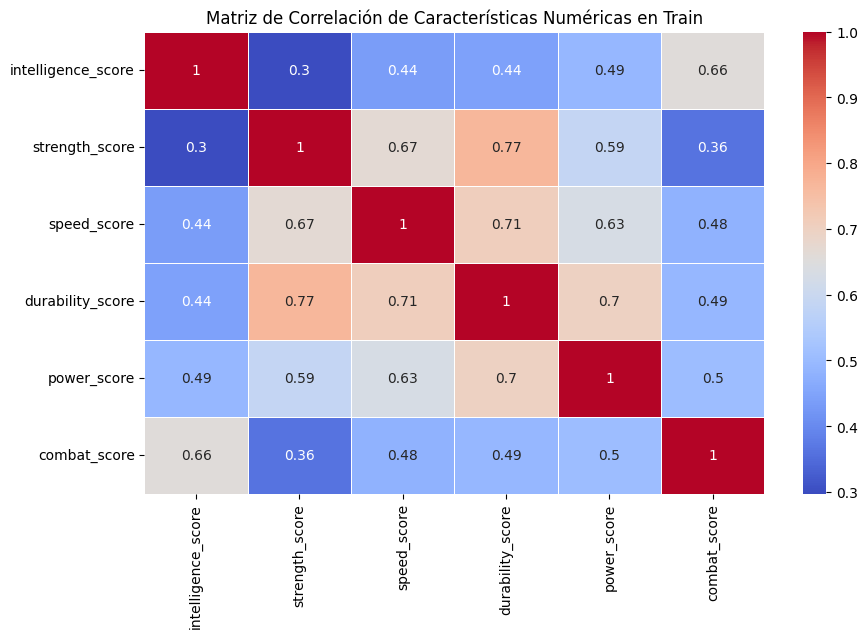

In [21]:
plt.figure(figsize=(10, 6))
sns.heatmap(X_train_num.corr(numeric_only=True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Matriz de Correlación de Características Numéricas en Train")
plt.show()

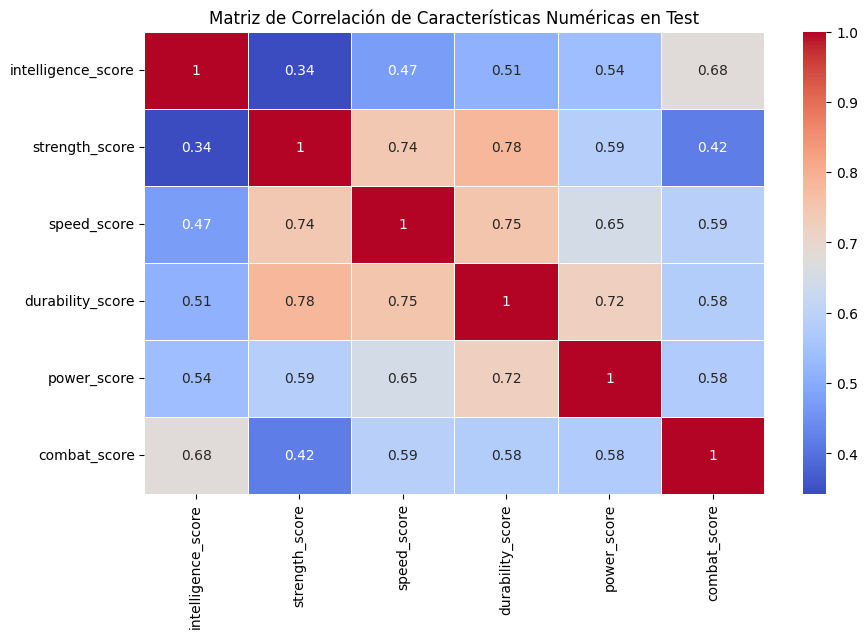

In [22]:
plt.figure(figsize=(10, 6))
sns.heatmap(X_test_num.corr(numeric_only=True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Matriz de Correlación de Características Numéricas en Test")
plt.show()

## 4.2 SHAP (SHapley Additive exPlanations) [0.6 Puntos]

### 4.2.1 Descripción [0.2 Puntos]

Responde las siguientes preguntas con tus propias palabras:

1. **¿Qué miden los SHAP values?** ¿En qué se diferencian de una medida de importancia global como PFI?
2. **¿Qué representa el `base_value` en un `waterfall_plot` de SHAP?** ¿Por qué es el punto de partida para interpretar una predicción individual?
3. **¿Por qué usar `TreeExplainer` para modelos basados en árboles?** ¿Qué ventaja ofrece respecto a un explainer genérico?

> **Respuesta:**

Shap values mide la constribución de cada variable en la predicción de un registro en específico. Para ello, primero evalúa la predicción del modelo con todas las variables. Luego, saca una variable y vuelve a calcular la predicción para ver cuánto cambio el resultado y cuanto aportabá la variable anterior. repite el proceso con todas las combinaciones posibles de variables y genera un valor SHAP que es el aporte marginal promedio de cada variable al resultado. Es decir, por ejemplo entrega que la variable "Comuna" aportó 30 millones en la predicción final del precio de una casa. A diferencia de PFI es que Shap es local, es decir explica variable por variable, de lo contrario PFI es global explicando como funciona todo el modelo en conjunto. Además Shap mide la dirección y magnitud del cambio de predicción del resultado final, en cambo PFI mide cánto empeora el error del modelo al eliminar cada variable. Finalmente, SHAP no necesita el valor real (target), sino que explica la salida del modelo. De lo contrario PFI depende del valor real para calcular métricas de error como R^2 o RMSE.

El base_value en un waterfall_plot de shap 

---

### 4.2.2 Implementación [0.2 Puntos]

**To-do:**
- [ ] Crear un `shap.TreeExplainer(lgbm_interp)` y calcular `shap_values` sobre `X_test_num`.
- [ ] `summary_plot` para ver importancia global y dirección del efecto (para la clase "Good").
- [ ] `waterfall_plot` para la predicción de una instancia cualquiera de `X_test_num`.

Graficando Summary Plot para la clase: Good


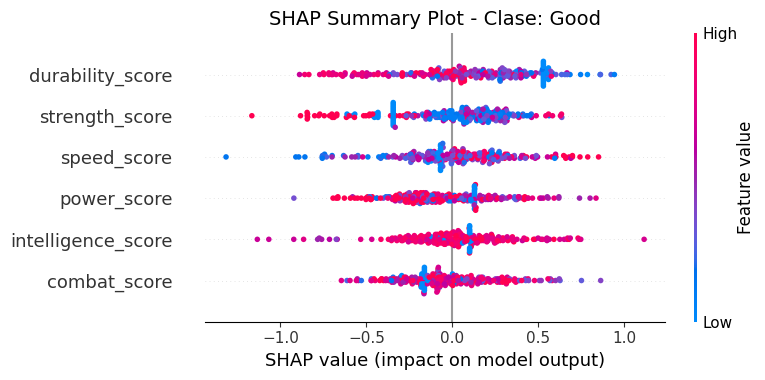

In [32]:
#### Código aquí ####
shapTree = shap.TreeExplainer(lgbm_interp)
shap_values = shapTree(X_test_num)

clase_good_idx = list(lgbm_interp.classes_).index("Good")

print(f"Graficando Summary Plot para la clase: {lgbm_interp.classes_[clase_good_idx]}")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values[:, :, clase_good_idx], X_test_num, show=False)
plt.title("SHAP Summary Plot - Clase: Good", fontsize=14)
plt.tight_layout()
plt.show()

Graficando Summary Plot para la clase: Bad


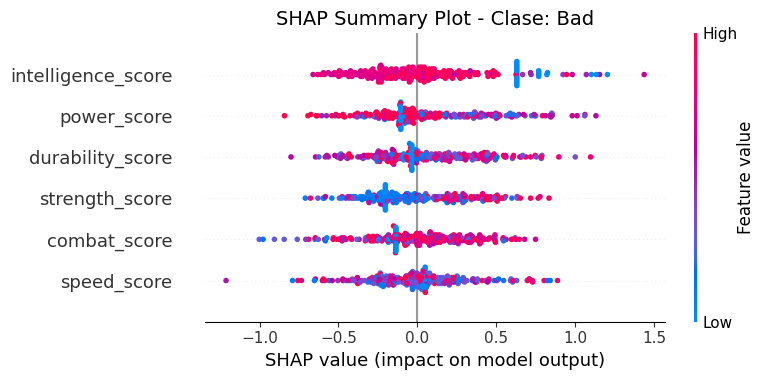

In [33]:
clase_bad_idx = list(lgbm_interp.classes_).index("Bad")

print(f"Graficando Summary Plot para la clase: {lgbm_interp.classes_[clase_bad_idx]}")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values[:, :, clase_bad_idx], X_test_num, show=False)
plt.title("SHAP Summary Plot - Clase: Bad", fontsize=14)
plt.tight_layout()
plt.show()

Graficando Summary Plot para la clase: Neutral


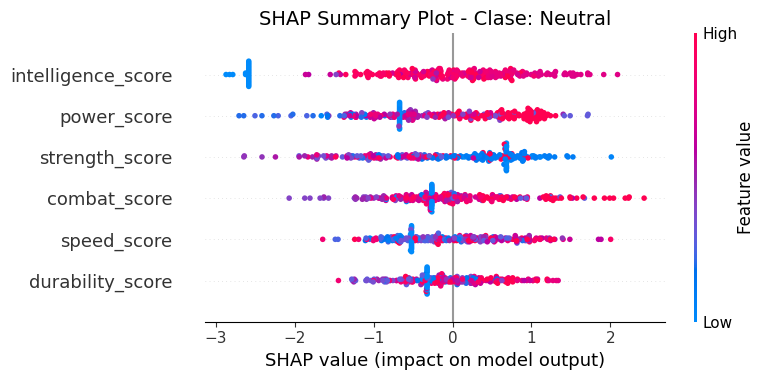

In [34]:
clase_Neutral_idx = list(lgbm_interp.classes_).index("Neutral")

print(f"Graficando Summary Plot para la clase: {lgbm_interp.classes_[clase_Neutral_idx]}")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values[:, :, clase_Neutral_idx], X_test_num, show=False)
plt.title("SHAP Summary Plot - Clase: Neutral", fontsize=14)
plt.tight_layout()
plt.show()

Graficando Waterfall Plot para la instancia 0


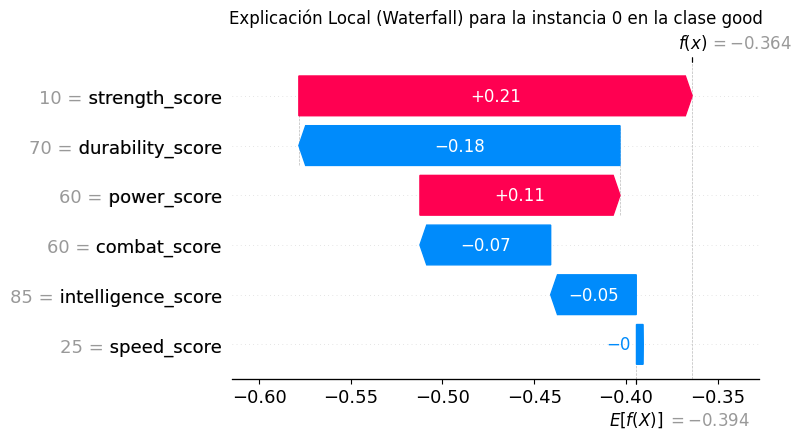

In [37]:
instancia_idx = 0

# nombre_personaje = X_test_num.index[instancia_idx]
print(f"Graficando Waterfall Plot para la instancia {instancia_idx}")

plt.figure(figsize=(10, 6))
# Pasamos los shap_values de esa fila específica y de la clase "Good"
shap.plots.waterfall(shap_values[instancia_idx, :, clase_good_idx], show=False)
plt.title(f"Explicación Local (Waterfall) para la instancia {instancia_idx} en la clase good", fontsize=12)
plt.tight_layout()
plt.show()

### 4.2.3 Pregunta de Cierre [0.2 Puntos]

1. ¿Qué diferencia existe entre Permutation Feature Importance y los SHAP values como medida de importancia de features?
2. Según el `waterfall_plot`, ¿qué features fueron las que más empujaron la predicción hacia su clase? Investiga el personaje seleccionado: ¿Tiene sentido dado su historia en los cómics?

> **Respuesta:**

In [ ]:
# Escribe aquí la respuesta

---

# 5. Predicción de Personajes No Etiquetados [0.5 Puntos]

<p align="center">
  <img src="https://pbs.twimg.com/media/DolotxUUYAAbg7f.jpg" width="350">
</p>

¡Llegó el momento de predecir `Vergil`, `Gorilla Girl` y `Bat-Cow`!

Usaremos el **mejor modelo** obtenido en la sección 3 (`pipe_lgbm_opt`) para predecir la alineación de los personajes no etiquetados.

**Nota:** Recuerda eliminar los NaN en `history_text` antes de predecir.

### 5.0 Predicción [0.2 Puntos]

**To-do:**
- [ ] Usar `pipe_lgbm_opt` para predecir `alignment` en `df_comics_no_label` (recuerda eliminar NaN en `history_text`).
- [ ] Filtrar y mostrar resultados para `Vergil`, `Gorilla Girl` y `Bat-Cow`.

In [ ]:
#### Código aquí ####
# Preparamos el DataFrame de predicciones para el conjunto sin etiquetas
df_comics_no_label = df_comics_no_label.dropna(subset=["history_text"])
df_comics_no_label = df_comics_no_label.drop(columns=["alignment"])

,name,real_name,full_name,overall_score,history_text,powers_text,intelligence_score,strength_score,speed_score,durability_score,...,has_flight,has_accelerated_healing,has_weapons_master,has_intelligence,has_reflexes,has_super_speed,has_durability,has_stamina,has_agility,has_super_strength
1,514A (Gotham),Bruce Wayne,NaN,10,He was one of the many prisoners of Indian Hil...,NaN,100,20,30,50,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
17,A'dal,NaN,NaN,7,"As with most of the naaru, little is known of ...",NaN,85,30,70,55,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
27,Agent Zero (FOX),David North,NaN,6,"During mid-late 1973, Zero was a member of Tea...",Zero can absorb kinetic energy to further incr...,90,10,25,25,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
31,Ajax (FOX),Francis,Francis Freeman,7,Ajax (born Francis Freeman) was a human who ga...,Ajax has claimed that the procedure to obtain ...,85,25,45,75,...,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0
46,A.M.A.Z.O. (CW),NaN,NaN,22,The Anti Meta-human Adaptive Zootomic Organism...,"With its metallic body, it easily overpowered ...",90,100,100,100,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1368,Vergil,Vergil Sparda,NaN,16,"Vergil, later also known as Nelo Angelo, is on...",NaN,90,75,95,90,...,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1396,Wendigo,Wendigo,NaN,6,The Wendigo are the result of an ancient curse...,NaN,65,80,75,75,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1431,XS (CW),Nora West-Allen,NaN,19,"According to Eobard Thawne, the daughter of Ba...",Nora possesses a natural connection to the Spe...,90,55,100,60,...,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0
1440,Yondu (MCU),Yondu,NaN,7,"Yondu Udonta was a Centaurian, leader of a key...","Yondu Udonta was a member of the Centaurians, ...",85,25,40,40,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [23]:
# Realizamos predicciones con el pipeline optimizado
predicciones_no_label = pipeline_lgbm_opt.predict(df_comics_no_label)
# Agregamos las predicciones al DataFrame original
df_comics_no_label["predicted_alignment"] = predicciones_no_label

In [30]:
# Filtramos para mostrar resultados para Vergil, Gorilla Girl y Bat Cow.
personajes_interes = ["Vergil", "Gorilla Girl", "Batcow"]
df_resultados = df_comics_no_label[df_comics_no_label["name"].isin(personajes_interes)][["name", "predicted_alignment"]]
df_resultados = df_resultados.drop_duplicates(subset=["name"]).reset_index(drop=True)
df_resultados

,name,predicted_alignment
0,Batcow,Good
1,Gorilla Girl,Good
2,Vergil,Good


### 5.1 Análisis de Predicciones [0.3 Puntos]

**Pregunta:** Comenta las predicciones obtenidas para `Vergil`, `Gorilla Girl` y `Bat-Cow`:

1. ¿Las predicciones te parecen razonables según lo que conoces (o puedes inferir) de estos personajes?
2. Conecta con la sección 4: ¿qué features numéricas habrían influido más en la predicción de **Bat-Cow** según el `waterfall_plot`? ¿Es consistente con la predicción obtenida aquí?

1. Las predicciones obtenidas para los personajes no etiquetados fueron las siguientes:
- Vergil: Predicción - "Good"
- Gorilla Girl: Predicción - "Good"
- Bat-Cow: Predicción - "Good"
Lo que tiene sentido para Vergil, ya que es un personaje que aunque tiene una historia compleja, generalmente se le considera un anti-héroe o incluso un héroe en algunos contextos. Para Gorilla Girl y Bat-Cow, aunque no son personajes tan conocidos, la predicción de "Good" podría ser razonable si se consideran sus características y habilidades, que podrían estar asociadas con comportamientos heroicos o altruistas.

2. 

# Conclusión

¡Eso ha sido todo para el lab de hoy! Recuerden que el laboratorio tiene un plazo de entrega de una semana y que **los días de atraso no se pueden utilizar para entregas de lab, solo para tareas**. Cualquier duda del laboratorio, no duden en contactarnos por mail o U-cursos.

<p align="center">
  <img src="https://media1.tenor.com/images/fb5bf7cc5a4acb91b4177672886a88ba/tenor.gif?itemid=5591338">
</p>